<a href="https://colab.research.google.com/github/mehrabbzz/Computer-Vision-Learning/blob/main/Processed_data__5_Transfer_LearningModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install split-folders

import splitfolders

input_folder = "/content/drive/MyDrive/Image Dataset/processed_224_tuned_gamma1_blur3_clahe0p8_grid12_open3"
output_folder = "/content/input"

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.7, 0.2, 0.1))

Copying files: 25000 files [10:43, 38.86 files/s] 


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

In [ ]:
# You can switch models easily

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import DenseNet201

In [ ]:
IMAGE_SIZE = [224, 224]
CLASS = 5

# VGG19

In [ ]:
# Choose ONE model only 👇

mod = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# mod = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = Xception(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in mod.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(mod.output)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

prediction = Dense(CLASS, activation='softmax')(x)

model = Model(inputs=mod.input, outputs=prediction)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 23,236,421 (88.64 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/input/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    '/content/input/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/input/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17500 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

csv_logger = CSVLogger('/content/training_log.csv')

callbacks = [checkpoint, csv_logger]

In [ ]:
history = model.fit(
    training_set,
    epochs=20,
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 287s 524ms/step - accuracy: 0.8747 - loss: 0.3393 - val_accuracy: 0.9168 - val_loss: 0.2296
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 283s 517ms/step - accuracy: 0.8866 - loss: 0.3081 - val_accuracy: 0.9182 - val_loss: 0.2141
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 285s 520ms/step - accuracy: 0.8955 - loss: 0.2858 - val_accuracy: 0.9150 - val_loss: 0.2148
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 291s 531ms/step - accuracy: 0.9047 - loss: 0.2571 - val_accuracy: 0.9334 - val_loss: 0.1726
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 285s 520ms/step - accuracy: 0.9076 - loss: 0.2430 - val_accuracy: 0.9392 - val_loss: 0.1576
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 289s 528ms/step - accuracy: 0.9118 - loss: 0.2366 - val_accuracy: 0.9338 - val_loss: 0.1740
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 286s 522ms/step - accuracy: 0.9177 - loss: 0.2239 - val_accuracy: 0.9364 - val_loss: 0.1516
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 288s 525ms/step - accuracy: 0.9201 -

In [ ]:
model.load_weights('/content/best_model.weights.h5')

loss, acc = model.evaluate(test_set)

print("Test Accuracy:", acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.9560 - loss: 0.1129
Test Accuracy: 0.9559999704360962


In [ ]:
y_pred = model.predict(test_set)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_set.classes

79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step


In [ ]:
# 12️⃣ Evaluate on test set
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.9213 - loss: 0.2301
Test Loss: 0.2301
Test Accuracy: 0.9213


In [ ]:
model.evaluate(test_set)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.9213 - loss: 0.2301


[0.23006729781627655, 0.9213114976882935]

In [ ]:
y_pred = model.predict(test_set)
y_true = test_set.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step


79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step


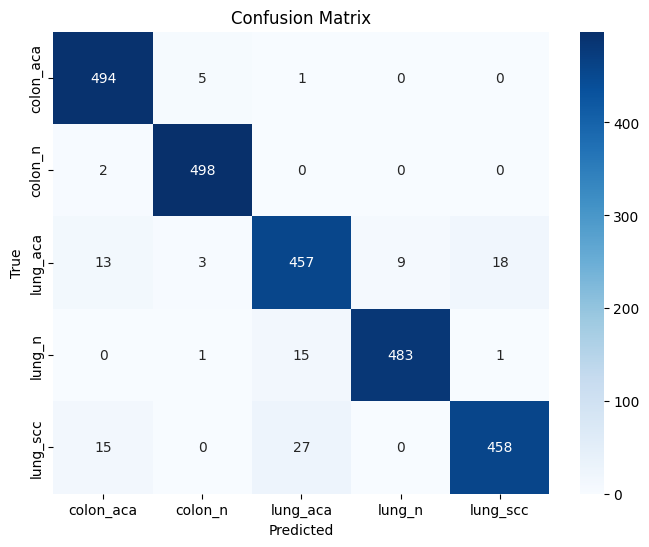

              precision    recall  f1-score   support

   colon_aca       0.94      0.99      0.96       500
     colon_n       0.98      1.00      0.99       500
    lung_aca       0.91      0.91      0.91       500
      lung_n       0.98      0.97      0.97       500
    lung_scc       0.96      0.92      0.94       500

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500



In [ ]:

# 13️⃣ Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

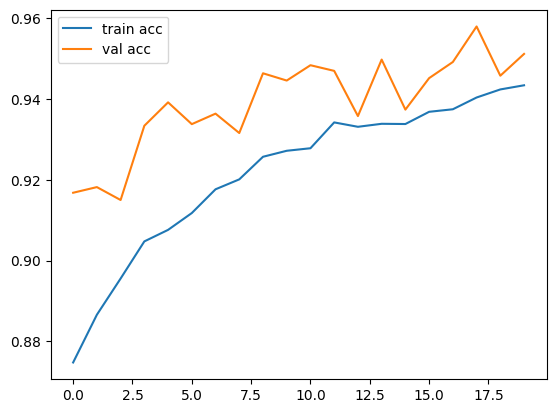

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/training_log.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.legend()
plt.show()

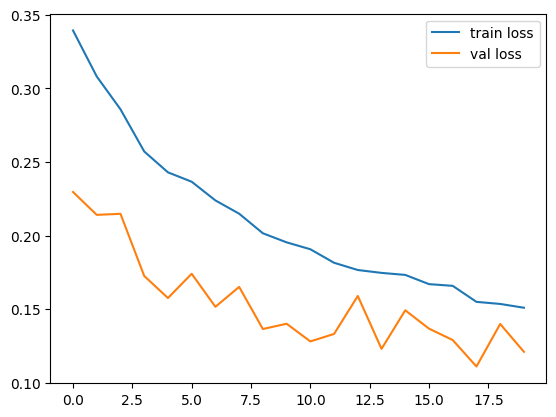

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')
plt.legend()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step


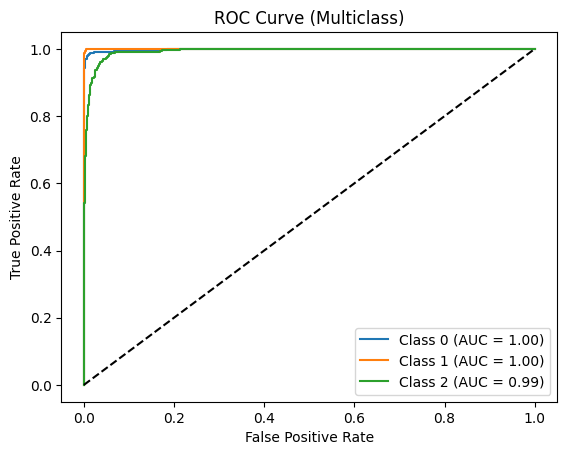

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 3
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass)')
plt.legend()
plt.show()

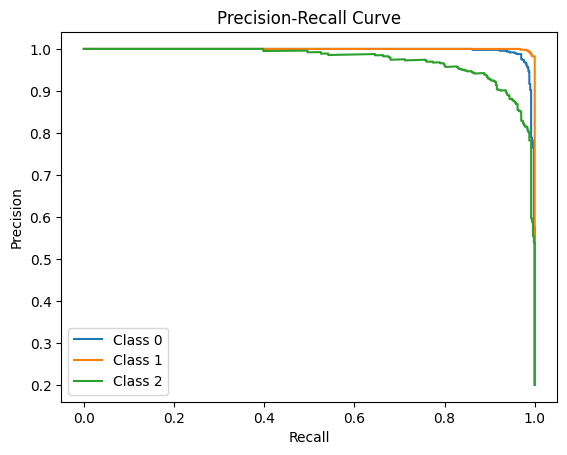

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

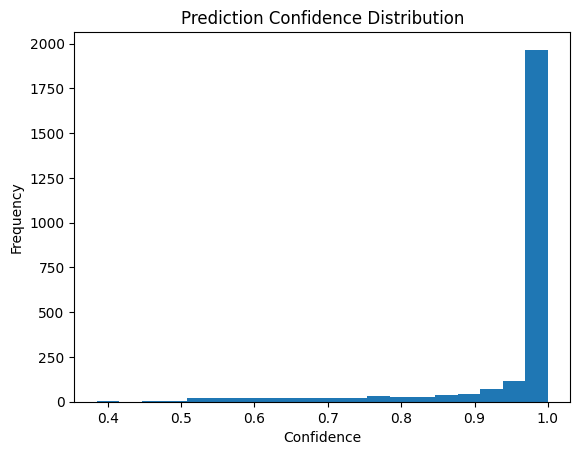

In [ ]:
confidence = np.max(y_pred, axis=1)

plt.figure()
plt.hist(confidence, bins=20)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()

# InceptionV3

In [ ]:
IMAGE_SIZE = [224, 224]
CLASS = 5

In [ ]:
# Choose ONE model only 👇

#mod = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
#mod = EfficientNetV2B0(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),weights='imagenet',include_top=False)
# mod = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
mod = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = Xception(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in mod.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(mod.output)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

prediction = Dense(CLASS, activation='softmax')(x)

model = Model(inputs=mod.input, outputs=prediction)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 28,357,157 (108.17 MB)

 Trainable params: 6,554,373 (25.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/input/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    '/content/input/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/input/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17500 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/best_inceptionv3_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

csv_logger = CSVLogger('/content/inceptionv3_training_log.csv')

callbacks = [checkpoint, csv_logger]

In [ ]:
history = model.fit(
    training_set,
    epochs=20,
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 286s 489ms/step - accuracy: 0.8151 - loss: 0.5048 - val_accuracy: 0.9150 - val_loss: 0.2276
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 242s 443ms/step - accuracy: 0.8740 - loss: 0.3392 - val_accuracy: 0.9358 - val_loss: 0.1867
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 241s 440ms/step - accuracy: 0.8814 - loss: 0.3164 - val_accuracy: 0.9478 - val_loss: 0.1458
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 240s 437ms/step - accuracy: 0.8909 - loss: 0.2876 - val_accuracy: 0.9492 - val_loss: 0.1388
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 262s 438ms/step - accuracy: 0.8950 - loss: 0.2745 - val_accuracy: 0.9526 - val_loss: 0.1330
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 237s 433ms/step - accuracy: 0.9028 - loss: 0.2609 - val_accuracy: 0.9518 - val_loss: 0.1292
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 250s 457ms/step - accuracy: 0.9098 - loss: 0.2496 - val_accuracy: 0.9528 - val_loss: 0.1276
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 249s 433ms/step - accuracy: 0.9071 -

In [ ]:
model.load_weights('/content/best_inceptionv3_model.weights.h5')

loss, acc = model.evaluate(test_set)

print("Test Accuracy:", acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.9640 - loss: 0.1017
Test Accuracy: 0.9639999866485596


In [ ]:
y_pred = model.predict(test_set)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_set.classes

79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step


In [ ]:
# 12️⃣ Evaluate on test set
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9640 - loss: 0.1017
Test Loss: 0.1017
Test Accuracy: 0.9640


79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step


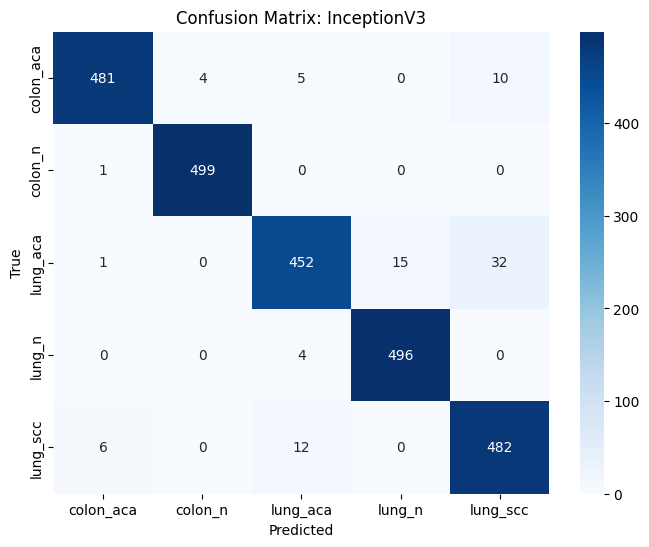

              precision    recall  f1-score   support

   colon_aca       0.98      0.96      0.97       500
     colon_n       0.99      1.00      1.00       500
    lung_aca       0.96      0.90      0.93       500
      lung_n       0.97      0.99      0.98       500
    lung_scc       0.92      0.96      0.94       500

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500



In [ ]:

# 13️⃣ Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: InceptionV3')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

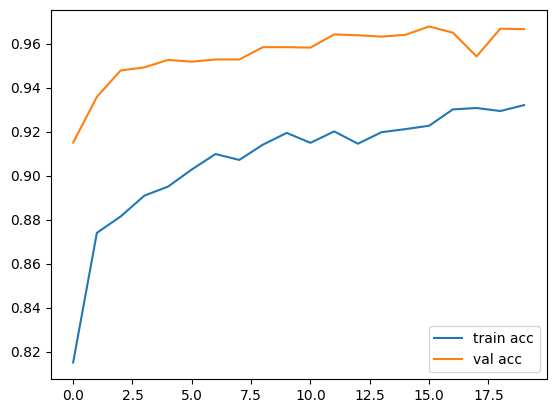

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/inceptionv3_training_log.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.legend()
plt.show()

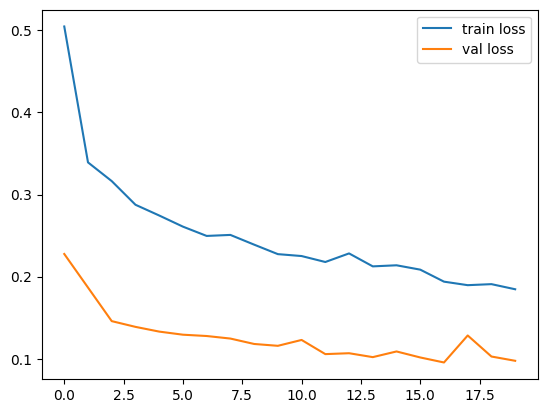

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')
plt.legend()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step


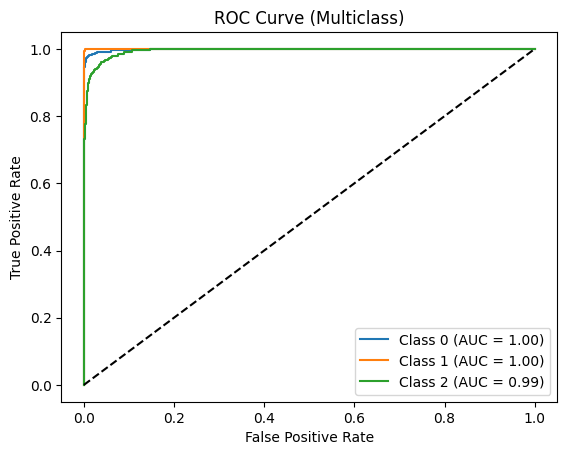

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 3
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass)')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

# Xception

In [ ]:
IMAGE_SIZE = [224, 224]
CLASS = 5

In [ ]:
# Choose ONE model only 👇

#mod = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# mod = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
mod = Xception(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in mod.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(mod.output)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

prediction = Dense(CLASS, activation='softmax')(x)

model = Model(inputs=mod.input, outputs=prediction)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 33,707,309 (128.58 MB)

 Trainable params: 12,845,829 (49.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/input/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    '/content/input/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/input/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17500 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/xception_best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

csv_logger = CSVLogger('/content/xception_training_log.csv')

callbacks = [checkpoint, csv_logger]

In [ ]:
history = model.fit(
    training_set,
    epochs=20,
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 344s 580ms/step - accuracy: 0.8236 - loss: 0.4728 - val_accuracy: 0.9182 - val_loss: 0.2153
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 265s 484ms/step - accuracy: 0.8742 - loss: 0.3427 - val_accuracy: 0.9402 - val_loss: 0.1620
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 259s 474ms/step - accuracy: 0.8871 - loss: 0.2984 - val_accuracy: 0.9288 - val_loss: 0.1805
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 266s 482ms/step - accuracy: 0.9011 - loss: 0.2717 - val_accuracy: 0.9372 - val_loss: 0.1571
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 262s 479ms/step - accuracy: 0.9025 - loss: 0.2633 - val_accuracy: 0.9338 - val_loss: 0.1724
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 261s 477ms/step - accuracy: 0.9051 - loss: 0.2571 - val_accuracy: 0.9486 - val_loss: 0.1348
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 258s 471ms/step - accuracy: 0.9111 - loss: 0.2403 - val_accuracy: 0.9472 - val_loss: 0.1303
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 262s 479ms/step - accuracy: 0.9146 -

In [ ]:
model.load_weights('/content/xception_best_model.weights.h5')

loss, acc = model.evaluate(test_set)

print("Test Accuracy:", acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 315ms/step - accuracy: 0.9596 - loss: 0.1017
Test Accuracy: 0.9595999717712402


79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step


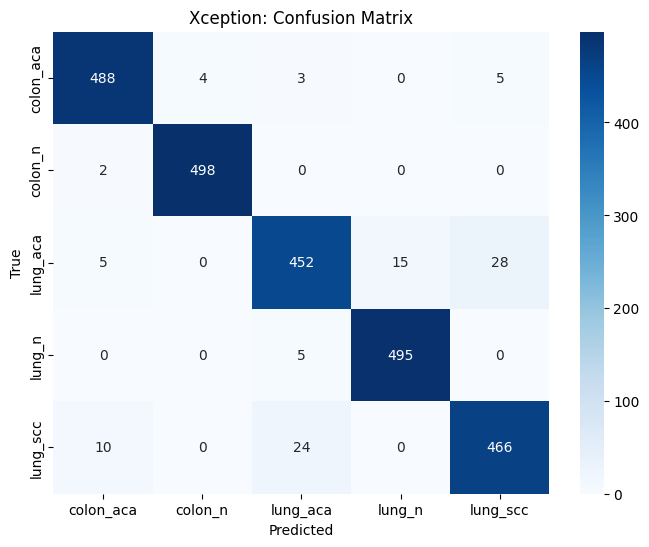

              precision    recall  f1-score   support

   colon_aca       0.97      0.98      0.97       500
     colon_n       0.99      1.00      0.99       500
    lung_aca       0.93      0.90      0.92       500
      lung_n       0.97      0.99      0.98       500
    lung_scc       0.93      0.93      0.93       500

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500



In [ ]:

# Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Xception: Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

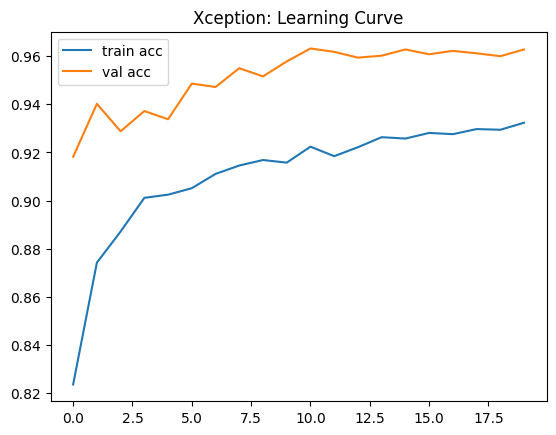

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/xception_training_log.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.title('Xception: Learning Curve')
plt.legend()
plt.show()

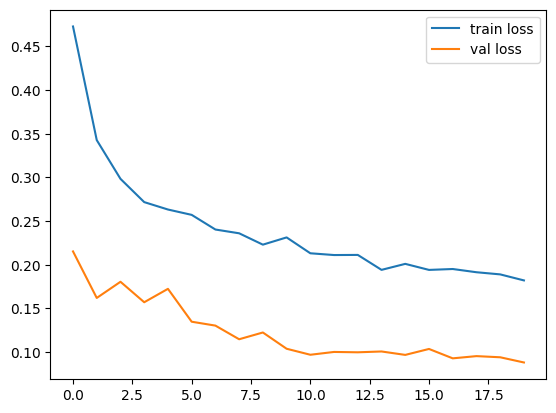

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')
plt.legend()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step


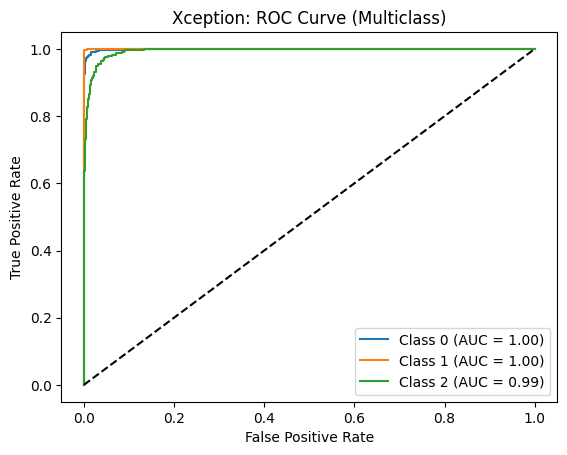

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 3
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Xception: ROC Curve (Multiclass)')
plt.legend()
plt.show()

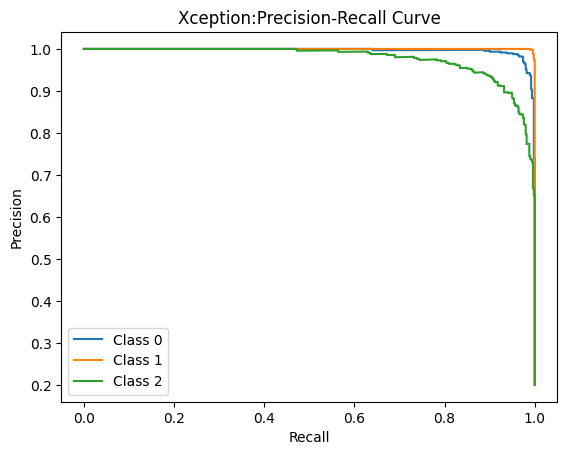

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Xception:Precision-Recall Curve')
plt.legend()
plt.show()

# VGG16

In [ ]:
IMAGE_SIZE = [224, 224]
CLASS = 5

In [ ]:
# Choose ONE model only 👇

#mod = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

mod = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = Xception(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
#mod = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in mod.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(mod.output)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

prediction = Dense(CLASS, activation='softmax')(x)

model = Model(inputs=mod.input, outputs=prediction)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,725 (68.39 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/input/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    '/content/input/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/input/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17500 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/VGG16_best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

csv_logger = CSVLogger('/content/VGG16_training_log.csv')

callbacks = [checkpoint, csv_logger]

In [ ]:
history = model.fit(
    training_set,
    epochs=20,
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 338s 574ms/step - accuracy: 0.8137 - loss: 0.5059 - val_accuracy: 0.9304 - val_loss: 0.2148
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 291s 531ms/step - accuracy: 0.8862 - loss: 0.3068 - val_accuracy: 0.9178 - val_loss: 0.2145
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 294s 538ms/step - accuracy: 0.9055 - loss: 0.2577 - val_accuracy: 0.9262 - val_loss: 0.1878
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 291s 532ms/step - accuracy: 0.9116 - loss: 0.2324 - val_accuracy: 0.9216 - val_loss: 0.1990
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 296s 541ms/step - accuracy: 0.9209 - loss: 0.2126 - val_accuracy: 0.9258 - val_loss: 0.1867
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 293s 534ms/step - accuracy: 0.9255 - loss: 0.2007 - val_accuracy: 0.9468 - val_loss: 0.1407
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 291s 532ms/step - accuracy: 0.9298 - loss: 0.1901 - val_accuracy: 0.9446 - val_loss: 0.1446
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 288s 527ms/step - accuracy: 0.9346 -

In [ ]:
model.load_weights('/content/VGG16_best_model.weights.h5')

loss, acc = model.evaluate(test_set)

print("Test Accuracy:", acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.9644 - loss: 0.0888
Test Accuracy: 0.9643999934196472


79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step


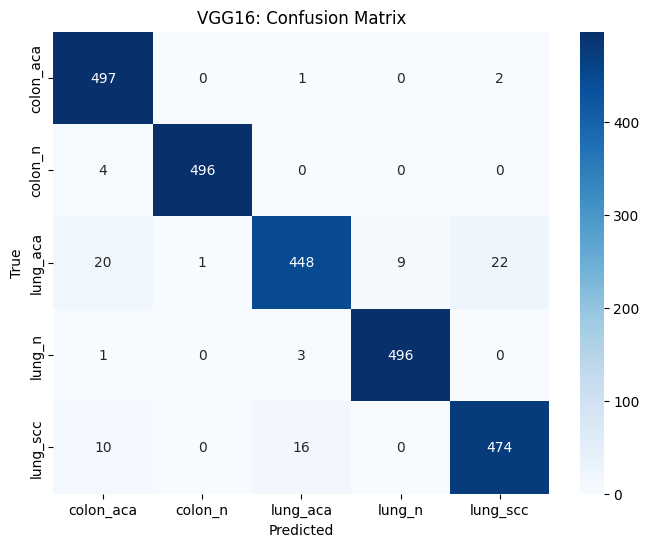

              precision    recall  f1-score   support

   colon_aca       0.93      0.99      0.96       500
     colon_n       1.00      0.99      0.99       500
    lung_aca       0.96      0.90      0.93       500
      lung_n       0.98      0.99      0.99       500
    lung_scc       0.95      0.95      0.95       500

    accuracy                           0.96      2500
   macro avg       0.96      0.96      0.96      2500
weighted avg       0.96      0.96      0.96      2500



In [ ]:

#Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('VGG16: Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

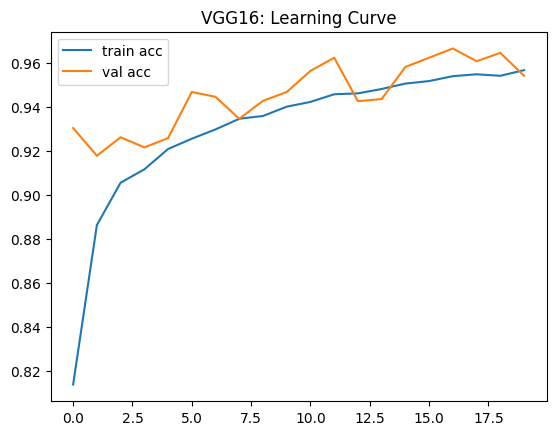

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/VGG16_training_log.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.title('VGG16: Learning Curve')
plt.legend()
plt.show()

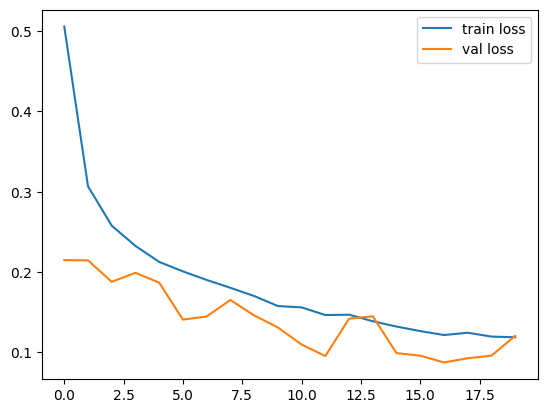

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')

plt.legend()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step


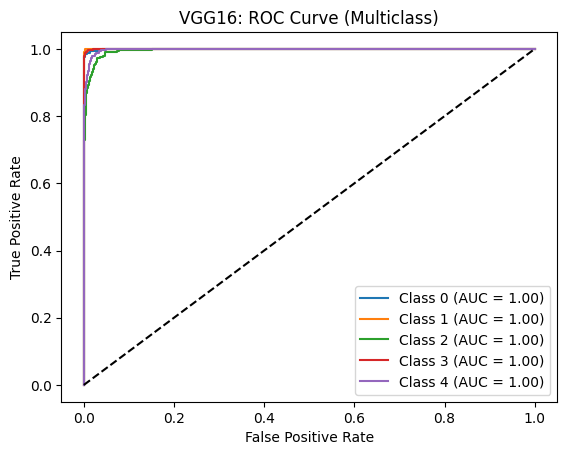

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 5 # Corrected to 5 classes
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4]) # Specify all 5 classes

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VGG16: ROC Curve (Multiclass)')
plt.legend()
plt.show()

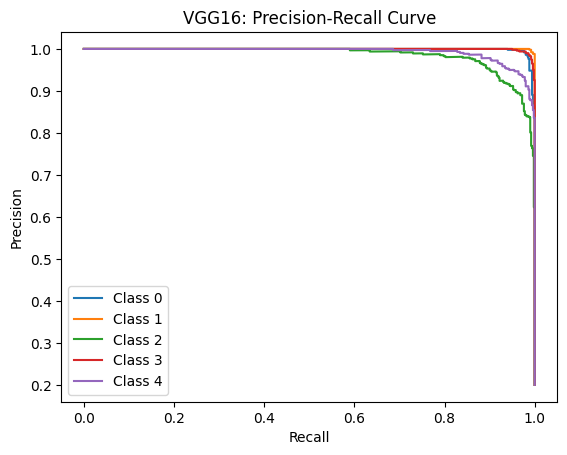

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('VGG16: Precision-Recall Curve')
plt.legend()
plt.show()

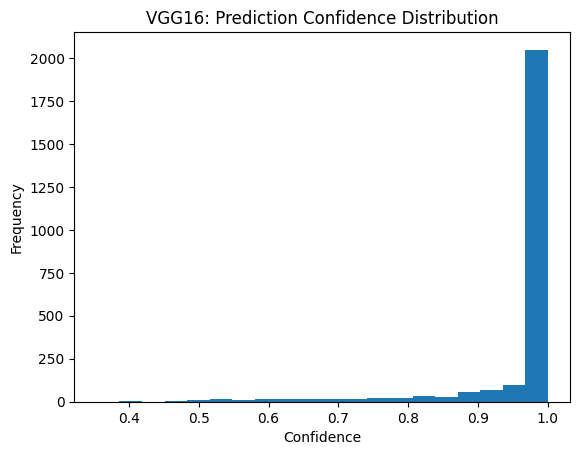

In [ ]:
confidence = np.max(y_pred, axis=1)

plt.figure()
plt.hist(confidence, bins=20)
plt.title('VGG16: Prediction Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()

# DenseNet201

In [ ]:
IMAGE_SIZE = [224, 224]
CLASS = 5

In [ ]:
# Choose ONE model only 👇

#mod = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# mod = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
# mod = Xception(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
mod = DenseNet201(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
for layer in mod.layers:
    layer.trainable = False

In [ ]:
x = Flatten()(mod.output)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

prediction = Dense(CLASS, activation='softmax')(x)

model = Model(inputs=mod.input, outputs=prediction)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 30,364,997 (115.83 MB)

 Trainable params: 12,043,013 (45.94 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    '/content/input/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_set = val_datagen.flow_from_directory(
    '/content/input/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    '/content/input/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 17500 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/DenseNEt201_best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

csv_logger = CSVLogger('/content/DenseNet201_training_log.csv')

callbacks = [checkpoint, csv_logger]

In [ ]:
history = model.fit(
    training_set,
    epochs=20,
    validation_data=val_set,
    steps_per_epoch=len(training_set),
    validation_steps=len(val_set),
    callbacks=callbacks
)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 400s 633ms/step - accuracy: 0.8537 - loss: 0.4037 - val_accuracy: 0.9414 - val_loss: 0.1565
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 267s 488ms/step - accuracy: 0.9054 - loss: 0.2500 - val_accuracy: 0.9542 - val_loss: 0.1169
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 272s 497ms/step - accuracy: 0.9217 - loss: 0.2162 - val_accuracy: 0.9578 - val_loss: 0.1016
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 268s 491ms/step - accuracy: 0.9257 - loss: 0.2011 - val_accuracy: 0.9536 - val_loss: 0.1282
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 268s 490ms/step - accuracy: 0.9366 - loss: 0.1760 - val_accuracy: 0.9680 - val_loss: 0.0874
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 265s 484ms/step - accuracy: 0.9346 - loss: 0.1698 - val_accuracy: 0.9666 - val_loss: 0.0786
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 264s 483ms/step - accuracy: 0.9400 - loss: 0.1639 - val_accuracy: 0.9632 - val_loss: 0.0945
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 324s 486ms/step - accuracy: 0.9403 -

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 420ms/step - accuracy: 0.9824 - loss: 0.0446
Test Loss: 0.0446
Test Accuracy: 0.9824


79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 469ms/step


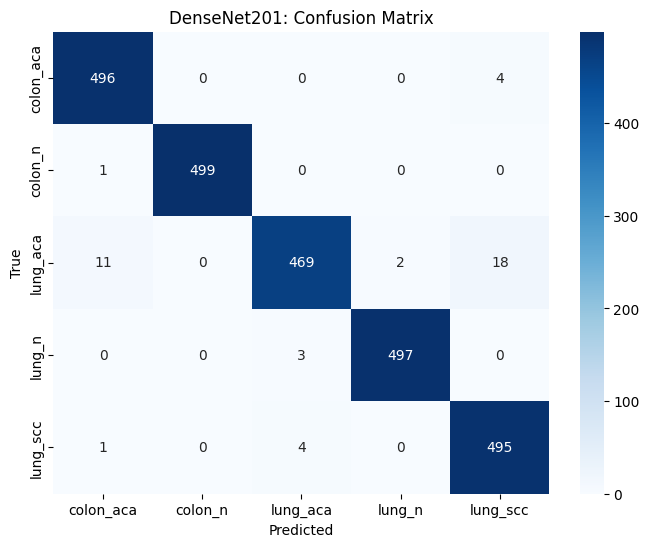

              precision    recall  f1-score   support

   colon_aca       0.97      0.99      0.98       500
     colon_n       1.00      1.00      1.00       500
    lung_aca       0.99      0.94      0.96       500
      lung_n       1.00      0.99      0.99       500
    lung_scc       0.96      0.99      0.97       500

    accuracy                           0.98      2500
   macro avg       0.98      0.98      0.98      2500
weighted avg       0.98      0.98      0.98      2500



In [ ]:

#  Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(test_set)
y_true = test_set.labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=test_set.class_indices.keys(),
            yticklabels=test_set.class_indices.keys(),
            cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('DenseNet201: Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_set.class_indices.keys())
print(class_report)

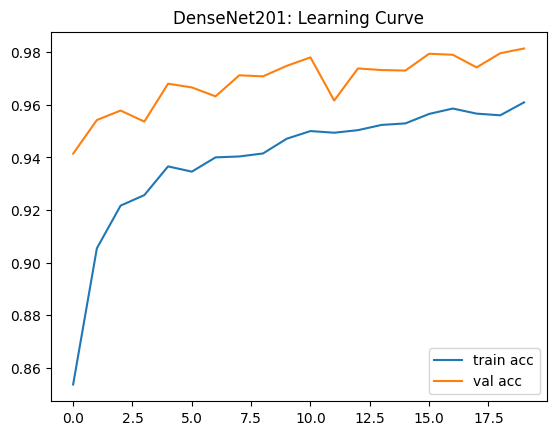

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/DenseNet201_training_log.csv')

plt.plot(data['accuracy'], label='train acc')
plt.plot(data['val_accuracy'], label='val acc')
plt.title('DenseNet201: Learning Curve')
plt.legend()
plt.show()

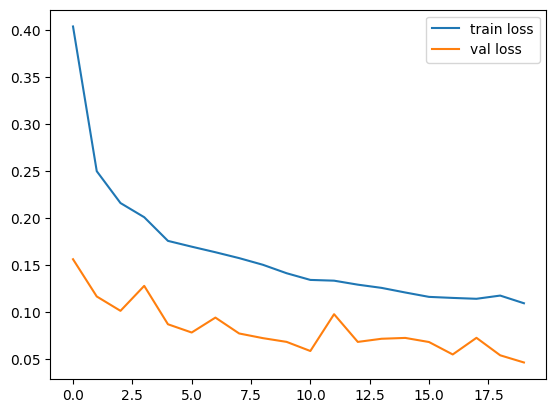

In [ ]:
plt.plot(data['loss'], label='train loss')
plt.plot(data['val_loss'], label='val loss')
plt.legend()
plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step


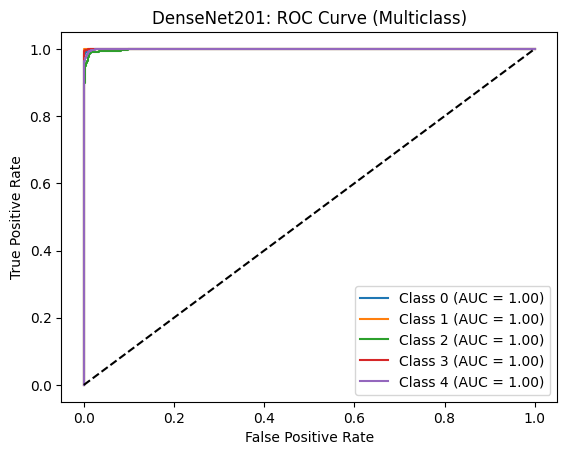

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels and predictions
y_true = test_set.labels
y_pred = model.predict(test_set)

# Convert labels to one-hot format
num_classes = 5 # Corrected to 5 classes
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4]) # Specify all 5 classes

# Plot ROC curve for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DenseNet201: ROC Curve (Multiclass)')
plt.legend()
plt.show()

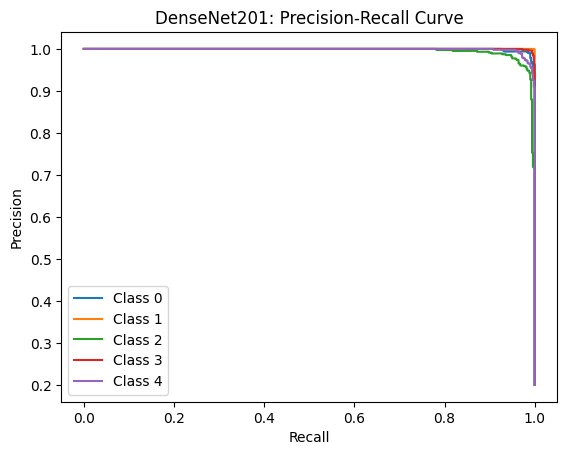

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('DenseNet201: Precision-Recall Curve')
plt.legend()
plt.show()

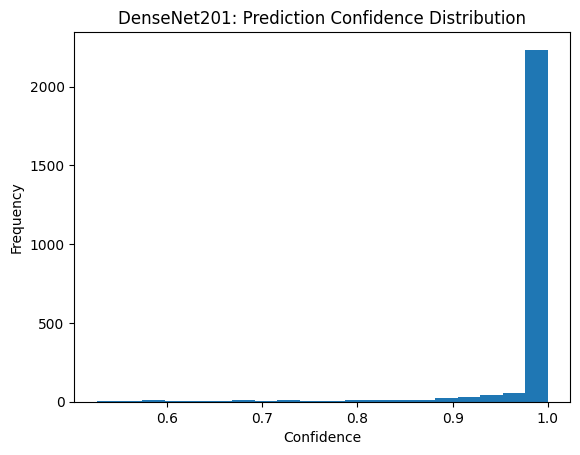

In [ ]:
confidence = np.max(y_pred, axis=1)

plt.figure()
plt.hist(confidence, bins=20)
plt.title('DenseNet201: Prediction Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.show()